In [2]:
import torch
import torch.nn as nn
from torchvision import models, transforms
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Load ResNet50
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load("resnet50_balanced.pth"))
model = model.to(device)
model.eval()

print("ResNet-50 loaded successfully!")

/Users/indraneelpothuri/miniforge3/envs/aiml/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/indraneelpothuri/miniforge3/envs/aiml/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet-50 loaded successfully!


In [3]:
target_layer = model.layer4
print(target_layer)

Sequential(
  (0): Bottleneck(
    (conv1): Conv2d(1024, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (downsample): Sequential(
      (0): Conv2d(1024, 2048, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): Bottleneck(
    (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): 

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [5]:
classes = ['ai', 'real']

image_path = "/Users/indraneelpothuri/Downloads/Gemini_Images/test/ai/photo_606@23-03-2023_14-55-32.jpg"

image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)
    confidence, predicted = torch.max(probs, 1)

pred_class = classes[predicted.item()]
conf_score = confidence.item()

print(f"Prediction: {pred_class}")
print(f"Confidence: {conf_score:.4f}")

Prediction: ai
Confidence: 0.9474


In [6]:
gradients = []
activations = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

# Register hooks
forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

# Forward
output = model(input_tensor)
pred_class_idx = output.argmax()

# Backward
model.zero_grad()
output[0, pred_class_idx].backward()

# Get gradients and activations
grad = gradients[0]
act = activations[0]

pooled_grad = torch.mean(grad, dim=[0, 2, 3])

for i in range(act.shape[1]):
    act[:, i, :, :] *= pooled_grad[i]

heatmap = torch.mean(act, dim=1).squeeze().cpu().detach().numpy()
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)

# Remove hooks
forward_handle.remove()
backward_handle.remove()

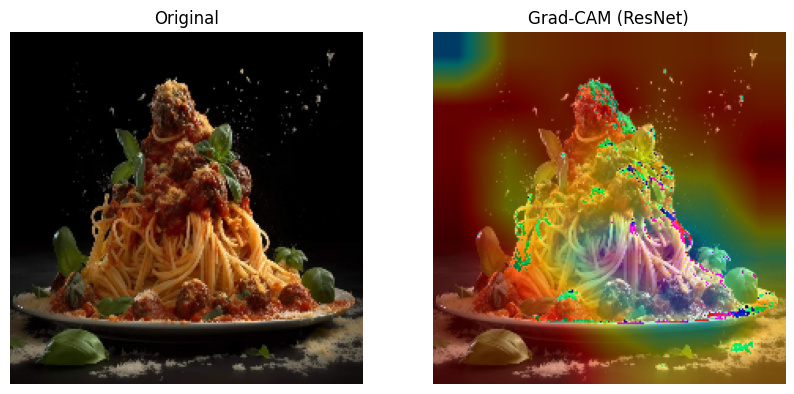

In [7]:
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))

heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

superimposed_img = heatmap_color * 0.4 + img

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Grad-CAM (ResNet)")
plt.imshow(superimposed_img.astype(np.uint8))
plt.axis("off")

plt.show()

In [8]:
import os
from PIL import Image
import torch

classes = ['ai', 'real']

def predict_folder(model, folder_path, transform, device):
    model.eval()

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            continue

        input_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(input_tensor)
            probs = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probs, 1)

        pred_class = classes[predicted.item()]
        conf_score = confidence.item()

        print(f"{img_name} → {pred_class} ({conf_score:.4f})")

In [9]:
predict_folder(model, "/Users/indraneelpothuri/Downloads/sample", transform, device)

photo_1@15-01-2023_22-04-16.jpg → ai (0.9997)
photo_5@15-01-2023_23-06-40_thumb.jpg → ai (0.8241)
photo_9@19-01-2023_21-54-42.jpg → ai (0.9962)
photo_11@20-01-2023_13-53-29_thumb.jpg → ai (0.9999)
photo_1@15-01-2023_22-04-16_thumb.jpg → ai (0.9996)
photo_10@19-01-2023_21-54-42.jpg → ai (0.9991)
photo_2@15-01-2023_22-04-16.jpg → ai (0.9996)
photo_4@15-01-2023_23-06-39_thumb.jpg → ai (0.9844)
photo_10@19-01-2023_21-54-42_thumb.jpg → ai (0.9988)
photo_11@20-01-2023_13-53-29.jpg → ai (1.0000)
photo_9@19-01-2023_21-54-42_thumb.jpg → ai (0.9952)
photo_6@15-01-2023_23-06-40.jpg → ai (0.9757)
photo_8@19-01-2023_21-54-42.jpg → ai (0.9998)
photo_2@15-01-2023_22-04-16_thumb.jpg → ai (0.9995)
photo_3@15-01-2023_22-04-16.jpg → ai (0.9996)
photo_4@15-01-2023_23-06-39.jpg → ai (0.9904)
photo_5@15-01-2023_23-06-40.jpg → ai (0.8723)
photo_7@19-01-2023_18-39-50.jpg → ai (0.9998)
photo_3@15-01-2023_22-04-16_thumb.jpg → ai (0.9996)
photo_6@15-01-2023_23-06-40_thumb.jpg → ai (0.9727)
photo_7@19-01-2023_18-

In [ ]:
import os
from PIL import Image
import torch

classes = ['ai', 'real']

def predict_folder(model, folder_path, transform, device):
    model.eval()

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            continue

        input_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(input_tensor)
            probs = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probs, 1)

        pred_class = classes[predicted.item()]
        conf_score = confidence.item()

        print(f"{img_name} → {pred_class} ({conf_score:.4f})")

In [12]:
predict_folder(model, "/Users/indraneelpothuri/Downloads/sample_2", transform, device)

IMG-20240605-WA0019.jpg → ai (0.9018)
photo_1@15-01-2023_22-04-16.jpg → ai (0.9997)
IMG-20240605-WA0018.jpg → ai (0.8832)
photo_5@15-01-2023_23-06-40_thumb.jpg → ai (0.8241)
photo_9@19-01-2023_21-54-42.jpg → ai (0.9962)
20260114_064545(1).jpg → ai (0.9760)
20251112_154931.jpg → ai (0.7282)
20250304_105449.jpg → ai (0.5563)
photo_11@20-01-2023_13-53-29_thumb.jpg → ai (0.9999)
20201224_214410.jpg → ai (0.9966)
20221113_124908.jpg → ai (0.9664)
20210214_134700.jpg → ai (0.6980)
20210129_134247.jpg → ai (0.8002)
20210211_205249.jpg → ai (0.9366)
20210311_120922.jpg → ai (0.9902)
20201231_222958.jpg → ai (0.9940)
photo_1@15-01-2023_22-04-16_thumb.jpg → ai (0.9996)
20210119_114640.jpg → ai (0.9523)
photo_10@19-01-2023_21-54-42.jpg → ai (0.9991)
20240513_112956.jpg → ai (0.8547)
photo_2@15-01-2023_22-04-16.jpg → ai (0.9996)
photo_4@15-01-2023_23-06-39_thumb.jpg → ai (0.9844)
photo_10@19-01-2023_21-54-42_thumb.jpg → ai (0.9988)
20210222_132239.jpg → ai (0.9533)
photo_11@20-01-2023_13-53-29.jpg